In [1]:
def quantum_numbers(n):
    result = []
    for l in range(n):
        for m in range(-l, l+1):
            result.append((n, l, m))
    return result

print(quantum_numbers(2))

[(2, 0, 0), (2, 1, -1), (2, 1, 0), (2, 1, 1)]


/var/folders/8f/013h3l1s4wg_jhshgbv7n8bc0000gn/T/ipykernel_70888/3407978990.py:11: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y = sph_harm(0, 1, phi, theta).real


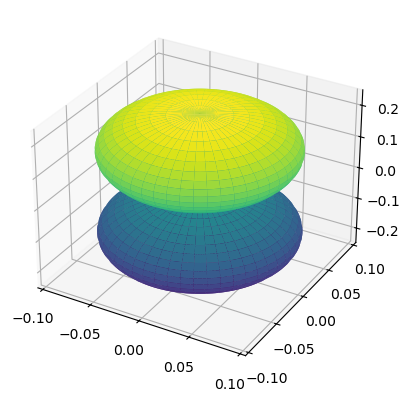

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm

# Parameters
theta = np.linspace(0, np.pi, 200)  
phi = np.linspace(0, 2*np.pi, 200)  
theta, phi = np.meshgrid(theta, phi)

# Example orbital: l=1, m=0 (p-orbital)
Y = sph_harm(0, 1, phi, theta).real
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Convert spherical → Cartesian for plotting
r = np.abs(Y)**2
x = r * np.sin(theta) * np.cos(phi)
y = r * np.sin(theta) * np.sin(phi)
z = r * np.cos(theta)

ax.plot_surface(x, y, z, cmap="viridis")
plt.show()

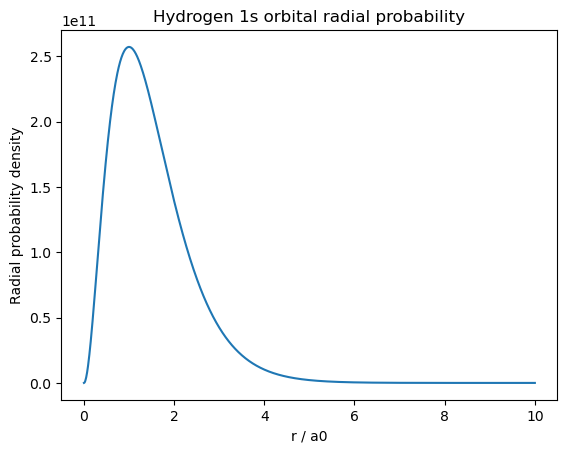

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
a0 = 0.529e-10  # Bohr radius (m)

# Radial wavefunction for hydrogen 1s
def R_1s(r):
    return (2/a0)**1.5 * np.exp(-r/a0)

# Probability density
r = np.linspace(0, 10*a0, 1000)
P = (R_1s(r)**2) * 4*np.pi*r**2

plt.plot(r/a0, P)
plt.xlabel("r / a0")
plt.ylabel("Radial probability density")
plt.title("Hydrogen 1s orbital radial probability")
plt.show()


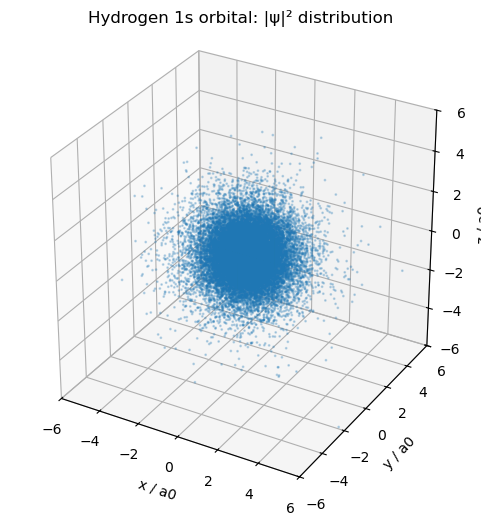

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Bohr radius (we'll keep units in a0 for simplicity)
a0 = 1.0  

# Number of random samples (increase for smoother cloud)
N = 30000  

# Radial distribution for hydrogen 1s orbital:
# |ψ|^2 ∝ r^2 * exp(-2r/a0), which is a Gamma distribution (k=3, θ=a0/2)
rng = np.random.default_rng(42)  # reproducibility
r = rng.gamma(shape=3.0, scale=a0/2.0, size=N)

# Sample uniform directions on the sphere
u = rng.uniform(-1.0, 1.0, size=N)        # cos(theta)
phi = rng.uniform(0.0, 2.0*np.pi, size=N) # azimuth angle

# Convert to Cartesian coordinates
sin_theta = np.sqrt(1.0 - u**2)
x = r * sin_theta * np.cos(phi)
y = r * sin_theta * np.sin(phi)
z = r * u

# Make 3D scatter plot
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x/a0, y/a0, z/a0, s=1, alpha=0.25)

# Labels and limits
ax.set_xlabel('x / a0')
ax.set_ylabel('y / a0')
ax.set_zlabel('z / a0')
ax.set_title('Hydrogen 1s orbital: |ψ|² distribution')
ax.set_box_aspect((1, 1, 1))
ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_zlim(-6, 6)

plt.show()


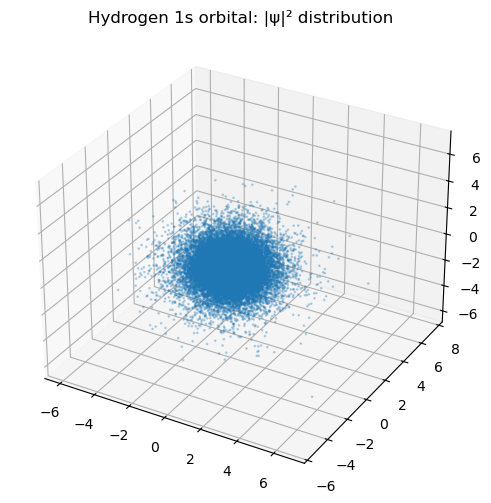

In [4]:
import numpy as np
import matplotlib.pyplot as plt

a0 = 1.0   # Bohr radius in atomic units
N = 30000  # number of samples

rng = np.random.default_rng(42)

# Sample radial distribution for hydrogen 1s orbital
r = rng.gamma(shape=3.0, scale=a0/2.0, size=N)

# Uniform sampling on the sphere
u = rng.uniform(-1.0, 1.0, size=N)
phi = rng.uniform(0, 2*np.pi, size=N)
sin_theta = np.sqrt(1 - u**2)

x = r * sin_theta * np.cos(phi)
y = r * sin_theta * np.sin(phi)
z = r * u

# Scatter plot
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x/a0, y/a0, z/a0, s=1, alpha=0.25)
ax.set_title("Hydrogen 1s orbital: |ψ|² distribution")
plt.show()

In [5]:
from scipy.integrate import quad
from scipy.optimize import minimize_scalar

# Trial wavefunction ψ(r) ~ exp(-alpha*r)
def energy(alpha):
    # Normalize
    norm, _ = quad(lambda r: 4*np.pi*r**2*np.exp(-2*alpha*r), 0, np.inf)
    
    # Kinetic + potential expectation values
    kinetic, _ = quad(lambda r: 4*np.pi*r**2 *
                      (alpha**2 * np.exp(-2*alpha*r)), 0, np.inf)
    potential, _ = quad(lambda r: -4*np.pi*r*np.exp(-2*alpha*r), 0, np.inf)
    
    return (kinetic + potential) / norm

res = minimize_scalar(energy, bounds=(0.1, 2), method="bounded")
print("Optimal α:", res.x)
print("Approx. ground-state energy:", res.fun)

Optimal α: 0.4999999999999952
Approx. ground-state energy: -0.24999999999999978


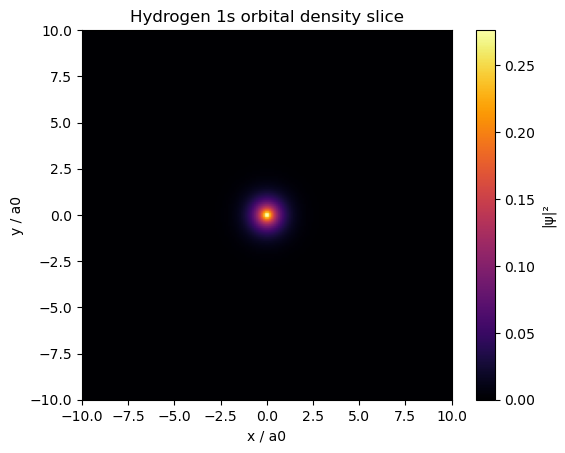

In [6]:
X, Y = np.meshgrid(np.linspace(-10,10,200), np.linspace(-10,10,200))
R = np.sqrt(X**2 + Y**2)
psi_1s = (1/np.sqrt(np.pi*a0**3)) * np.exp(-R/a0)
plt.imshow(np.abs(psi_1s)**2, extent=(-10,10,-10,10), cmap="inferno")
plt.colorbar(label="|ψ|²")
plt.title("Hydrogen 1s orbital density slice")
plt.xlabel("x / a0")
plt.ylabel("y / a0")
plt.show()

In [7]:
from scipy.integrate import quad
from scipy.optimize import minimize_scalar
import numpy as np

def energy(alpha):
    norm, _ = quad(lambda r: 4*np.pi*r**2*np.exp(-2*alpha*r), 0, np.inf)
    kinetic, _ = quad(lambda r: 4*np.pi*r**2*(alpha**2*np.exp(-2*alpha*r)), 0, np.inf)
    potential, _ = quad(lambda r: -4*np.pi*r*np.exp(-2*alpha*r), 0, np.inf)
    return (kinetic + potential) / norm

res = minimize_scalar(energy, bounds=(0.1, 2), method="bounded")
print("Optimal α:", res.x)
print("Approx ground-state energy (Hartree):", res.fun)


Optimal α: 0.4999999999999952
Approx ground-state energy (Hartree): -0.24999999999999978


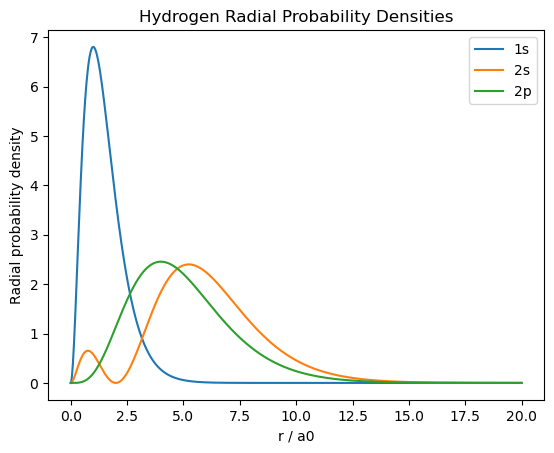

In [8]:
import numpy as np
import matplotlib.pyplot as plt

a0 = 1.0
r = np.linspace(0, 20*a0, 1000)

def R_1s(r): return 2/a0**1.5 * np.exp(-r/a0)
def R_2s(r): return (1/(2*np.sqrt(2*a0**3))) * (2 - r/a0) * np.exp(-r/(2*a0))
def R_2p(r): return (1/(2*np.sqrt(6*a0**3))) * (r/a0) * np.exp(-r/(2*a0))

P_1s = 4*np.pi * r**2 * R_1s(r)**2
P_2s = 4*np.pi * r**2 * R_2s(r)**2
P_2p = 4*np.pi * r**2 * R_2p(r)**2

plt.plot(r/a0, P_1s, label="1s")
plt.plot(r/a0, P_2s, label="2s")
plt.plot(r/a0, P_2p, label="2p")
plt.xlabel("r / a0")
plt.ylabel("Radial probability density")
plt.title("Hydrogen Radial Probability Densities")
plt.legend()
plt.show()


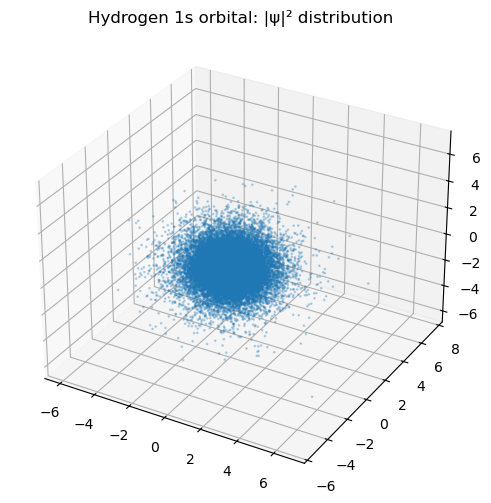

In [9]:
import numpy as np
import matplotlib.pyplot as plt

a0 = 1.0
N = 30000
rng = np.random.default_rng(42)

r = rng.gamma(shape=3.0, scale=a0/2.0, size=N)
u = rng.uniform(-1.0, 1.0, size=N)
phi = rng.uniform(0, 2*np.pi, size=N)
sin_theta = np.sqrt(1 - u**2)

x = r * sin_theta * np.cos(phi)
y = r * sin_theta * np.sin(phi)
z = r * u

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x/a0, y/a0, z/a0, s=1, alpha=0.25)
ax.set_title("Hydrogen 1s orbital: |ψ|² distribution")
plt.show()